# Phần 1: Cài đặt và tải dữ liệu

**Bước 1: Cài đặt thư viện datasets**

In [3]:
# Gỡ cài đặt cũ để dọn dẹp (thêm -y để không hỏi xác nhận)
!pip uninstall pyarrow datasets -y

# Cài đặt lại pyarrow (buộc tải bản mới nhất, không dùng cache)
print("Đang cài đặt lại pyarrow...")
!pip install --no-cache-dir pyarrow

# Cài đặt lại datasets (nó sẽ tự động dùng pyarrow mới)
print("Đang cài đặt lại datasets...")
!pip install datasets

print("Đã cài đặt lại xong!")

Found existing installation: pyarrow 21.0.0
Uninstalling pyarrow-21.0.0:
  Successfully uninstalled pyarrow-21.0.0
Found existing installation: datasets 4.2.0
Uninstalling datasets-4.2.0:
  Successfully uninstalled datasets-4.2.0
Đang cài đặt lại pyarrow...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 297.8 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
pylibcudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 21.0.0 which is incompatible.
cudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 21.0.0 which is incompatible.
bigframes 2.12.0 requires google-cloud-bigquery[bqstorage,pandas]>=3.31.0, but you have google-cloud-bigquery

**Bước 2: Import các thư viện chính**

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, transforms
from datasets import load_dataset # Thư viện mới
from collections import Counter
import os
import time
import copy
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image # Dùng cho transforms
import torch.nn.functional as F
from sklearn.metrics import roc_curve
from tqdm.notebook import tqdm # Dùng tqdm.notebook để hiển thị đẹp trên Kaggle

print("Đã import các thư viện.")

Đã import các thư viện.


**Bước 3: Thiết lập thiết bị (GPU)**

In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Sử dụng thiết bị: {DEVICE}")

Sử dụng thiết bị: cuda


**Bước 4: Tải dataset từ Hugging Face**

In [6]:
try:
    # Tải dataset (sẽ mất vài phút)
    hf_dataset = load_dataset("nguyenkhoa/antispoofing-3")
    
    print("Tải dataset Hugging Face thành công!")
    # In ra để xem cấu trúc
    print(hf_dataset)
    
except Exception as e:
    print(f"LỖI: Không tải được dataset. Hãy chắc chắn bạn đã bật Internet: {e}")

README.md:   0%|          | 0.00/706 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/29 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/29 [00:00<?, ?it/s]

data/train-00000-of-00029.parquet:   0%|          | 0.00/483M [00:00<?, ?B/s]

data/train-00001-of-00029.parquet:   0%|          | 0.00/527M [00:00<?, ?B/s]

...

data/eval-00003-of-00004.parquet:   0%|          | 0.00/450M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/93964 [00:00<?, ? examples/s]

Generating eval split:   0%|          | 0/10441 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/29 [00:00<?, ?it/s]

Tải dataset Hugging Face thành công!
DatasetDict({
    train: Dataset({
        features: ['image_path', 'label', 'cropped_image', 'bbox', 'image', 'labels', 'labelNames'],
        num_rows: 93964
    })
    eval: Dataset({
        features: ['image_path', 'label', 'cropped_image', 'bbox', 'image', 'labels', 'labelNames'],
        num_rows: 10441
    })
})


**Bước 5: Khám phá nhãn của dữ liệu**

In [7]:
if 'hf_dataset' in locals():
    
    CLASS_NAMES = ['real', 'spoof']
    print(f"Tên các lớp (đã tự định nghĩa): {CLASS_NAMES}")
    
    # Giả định mapping (Dựa trên tên)
    # 0 = real, 1 = spoof (Đây là chuẩn chung của dataset này)
    print(f"Giả định: 0 = {CLASS_NAMES[0]}, 1 = {CLASS_NAMES[1]}")
    
else:
    print("LỖI: hf_dataset chưa được tải.")

Tên các lớp (đã tự định nghĩa): ['real', 'spoof']
Giả định: 0 = real, 1 = spoof


In [8]:
from collections import Counter
import numpy as np # Import numpy if you haven't already

# Ensure CLASS_NAMES is defined (from previous Step 5)
if 'CLASS_NAMES' not in locals():
    CLASS_NAMES = ['real', 'spoof'] 
    print("Defined CLASS_NAMES = ['real', 'spoof']")


if 'hf_dataset' in locals() and 'CLASS_NAMES' in locals():
    print("--- Phân bố nhãn ---")
    
    # 1. Kiểm tra tập Train
    try:
        # Access the 'label' column directly
        train_labels = hf_dataset['train']['label'] 
        train_counts = Counter(train_labels)
        
        print("\nTập Train:")
        for label_index, count in sorted(train_counts.items()): # Sort by index 0, 1
             label_name = CLASS_NAMES[label_index] 
             print(f"  - {label_name} (Nhãn {label_index}): {count} mẫu")
             
    except Exception as e:
        print(f"Lỗi khi kiểm tra tập train: {e}")

    # 2. Kiểm tra tập Eval (since 'test' split is not shown)
    if 'eval' in hf_dataset:
         try:
            eval_labels = hf_dataset['eval']['label']
            eval_counts = Counter(eval_labels)
            
            print("\nTập Eval:")
            for label_index, count in sorted(eval_counts.items()):
                 label_name = CLASS_NAMES[label_index]
                 print(f"  - {label_name} (Nhãn {label_index}): {count} mẫu")
                 
         except Exception as e:
            print(f"Lỗi khi kiểm tra tập eval: {e}")

else:
    print("Lỗi: 'hf_dataset' hoặc 'CLASS_NAMES' chưa được định nghĩa.")
    print("Vui lòng chạy lại các cell code tải dataset và xác định CLASS_NAMES trước.")

--- Phân bố nhãn ---

Tập Train:
  - real (Nhãn 0): 30924 mẫu
  - spoof (Nhãn 1): 63040 mẫu

Tập Eval:
  - real (Nhãn 0): 3430 mẫu
  - spoof (Nhãn 1): 7011 mẫu


**Bước 6: Định nghĩa Data Transforms (với Augmentation)**

In [9]:
INPUT_SIZE = 224 # ResNet-18 thường dùng 224x224

# Định nghĩa các phép biến đổi
train_transforms = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5), # Lật ngang ngẫu nhiên
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Đổi màu
    transforms.ToTensor(), # Chuyển thành Tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Chuẩn hóa
])

test_transforms = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(), # Tập test không cần augmentation
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("Đã định nghĩa Data Transforms.")

Đã định nghĩa Data Transforms.


**Bước 7: Áp dụng Transforms vào Dataset**

In [10]:
# Tác vụ: Định nghĩa hàm "gom lô" (collate_fn) tùy chỉnh
# SỬ DỤNG CỘT 'cropped_image' THAY VÌ 'image'

def collate_fn_train(batch):
    """
    Hàm này nhận 1 list (danh sách) các 'example' từ dataset.
    Mỗi example là 1 dict: {'cropped_image': <ảnh PIL>, 'label': <số>}
    """
    images = []
    labels = []
    
    for item in batch:
        # === THAY ĐỔI TẠI ĐÂY ===
        # 1. Lấy ảnh PIL từ cột 'cropped_image' và áp dụng transform
        try:
            # Giả định 'cropped_image' chứa đối tượng ảnh PIL
            transformed_image = train_transforms(item['cropped_image']) 
            images.append(transformed_image)
            
            # 2. Lấy nhãn (giữ nguyên)
            labels.append(item['label'])
        except Exception as e:
            # Bỏ qua nếu ảnh bị lỗi (ví dụ: None)
            # print(f"Cảnh báo: Bỏ qua ảnh lỗi trong batch train - {e}")
            pass
        # ======================
    
    # Kiểm tra xem có ảnh nào trong batch không
    if not images:
        # Trả về batch rỗng nếu tất cả ảnh bị lỗi
        return {'image': torch.empty(0), 'label': torch.empty(0)}
        
    # 3. "Xếp chồng" (stack) các ảnh thành 1 batch tensor duy nhất
    # và chuyển list nhãn thành 1 tensor
    return {
        'image': torch.stack(images),
        'label': torch.tensor(labels, dtype=torch.long)
    }

def collate_fn_test(batch):
    """
    Tương tự như trên, nhưng dùng 'test_transforms' và cột 'cropped_image'
    """
    images = []
    labels = []
    
    for item in batch:
        # === THAY ĐỔI TẠI ĐÂY ===
        # 1. Lấy ảnh PIL từ cột 'cropped_image' và áp dụng test_transforms
        try:
            transformed_image = test_transforms(item['cropped_image']) 
            images.append(transformed_image)
            
            # 2. Lấy nhãn (giữ nguyên)
            labels.append(item['label'])
        except Exception as e:
            # print(f"Cảnh báo: Bỏ qua ảnh lỗi trong batch test - {e}")
            pass
        # ======================

    if not images:
        return {'image': torch.empty(0), 'label': torch.empty(0)}
        
    # 3. Xếp chồng
    return {
        'image': torch.stack(images),
        'label': torch.tensor(labels, dtype=torch.long)
    }

print("Đã định nghĩa các hàm collate_fn (sử dụng 'cropped_image').")

Đã định nghĩa các hàm collate_fn (sử dụng 'cropped_image').


# Phần 2: Huấn luyện mô hình

**Bước 8: Tạo DataLoaders**

In [11]:
# Tác vụ: Tạo DataLoaders (SỬ DỤNG collate_fn TÙY CHỈNH)

if 'hf_dataset' in locals():
    # QUAN TRỌNG: Đảm bảo dataset ở định dạng gốc (không có format)
    hf_dataset.set_format(type=None, columns=None)

    # 1. Tạo loader cho tập train
    train_loader = DataLoader(
        hf_dataset['train'], 
        batch_size=32, 
        shuffle=True, 
        num_workers=2,
        collate_fn=collate_fn_train # <-- DÙNG HÀM MỚI
    )
    
    # 2. Tạo loader cho tập test
    test_loader = DataLoader(
        hf_dataset['eval'], 
        batch_size=32, 
        shuffle=False, 
        num_workers=2,
        collate_fn=collate_fn_test # <-- DÙNG HÀM MỚI
    )
    
    # 3. Gói lại (Giữ nguyên)
    dataloaders = {'train': train_loader, 'test': test_loader}
    dataset_sizes = {'train': len(hf_dataset['train']), 'test': len(hf_dataset['eval'])}
    
    print(f"Đã tạo DataLoaders (chế độ on-the-fly).")
    print(f"Số ảnh train: {dataset_sizes['train']}, Số ảnh test: {dataset_sizes['test']}")
else:
    print("Lỗi: hf_dataset không tồn tại. Vui lòng chạy lại Bước 4.")

Đã tạo DataLoaders (chế độ on-the-fly).
Số ảnh train: 93964, Số ảnh test: 10441


In [12]:
import torch
import numpy as np # Đảm bảo đã import
from collections import Counter # Nếu cần đếm lại

# --- CẬP NHẬT SỐ LƯỢNG MẪU ---
num_real_train = 30924 # <--- Số đã sửa
num_spoof_train = 63040
total_train = num_real_train + num_spoof_train

print(f"Số lượng train: Real={num_real_train}, Spoof={num_spoof_train}")

# Tính trọng số (weight)
weight_real = total_train / num_real_train
weight_spoof = total_train / num_spoof_train

# Tạo tensor trọng số (theo đúng thứ tự lớp: 0=real, 1=spoof)
# Chuyển sang thiết bị (DEVICE) đã định nghĩa
if 'DEVICE' not in locals():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_weights = torch.tensor([weight_real, weight_spoof], dtype=torch.float32).to(DEVICE)

print(f"Trọng số tính toán (đã sửa): Real={weight_real:.3f}, Spoof={weight_spoof:.3f}")
print(f"Tensor trọng số sẽ dùng: {class_weights}")

Số lượng train: Real=30924, Spoof=63040
Trọng số tính toán (đã sửa): Real=3.039, Spoof=1.491
Tensor trọng số sẽ dùng: tensor([3.0385, 1.4905], device='cuda:0')


**Bước 9: Định nghĩa Model, Loss, Optimizer**

In [13]:
# Tải ResNet-18 đã huấn luyện trước
model_fas = models.resnet18(pretrained=True)

# Đóng băng các lớp cũ
for param in model_fas.parameters():
    param.requires_grad = False

# Thay thế lớp cuối cùng (2 lớp: real, spoof)
num_ftrs = model_fas.fc.in_features
model_fas.fc = nn.Linear(num_ftrs, len(CLASS_NAMES)) 

# Chuyển model sang GPU
model_fas = model_fas.to(DEVICE)

# Định nghĩa hàm loss
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Định nghĩa optimizer (chỉ huấn luyện lớp cuối)
optimizer = optim.Adam(model_fas.fc.parameters(), lr=0.001)

print("Đã tải và chuẩn bị mô hình ResNet-18.")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 161MB/s] 


Đã tải và chuẩn bị mô hình ResNet-18.


**Bước 10: Xây dựng hàm huấn luyện mô hình**

In [14]:
# Tác vụ: Định nghĩa hàm Huấn luyện (PHIÊN BẢN MỚI, CÓ THANH TIẾN TRÌNH)
# Lưu checkpoint dựa trên TEST LOSS thấp nhất

def train_model(model, criterion, optimizer, dataloaders, num_epochs=30):
    since = time.time()
    
    best_loss = np.Inf 
    best_model_wts = copy.deepcopy(model.state_dict())
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)
        
        for phase in ['train', 'test']:
            if phase == 'train': model.train()
            else: model.eval()
            
            running_loss = 0.0
            running_corrects = 0
            
            # === THAY ĐỔI DUY NHẤT TẠI ĐÂY ===
            # Bọc dataloader bằng tqdm() để hiển thị thanh tiến trình
            # Thêm 'desc' để mô tả thanh tiến trình đang chạy gì
            
            progress_bar = tqdm(dataloaders[phase], desc=f"{phase.title()} Epoch {epoch+1}")
            
            for batch in progress_bar:
            # ===============================
            
                inputs = batch['image'].to(DEVICE)
                labels = batch['label'].to(DEVICE)
                
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
                # (Tùy chọn) Cập nhật loss/acc lên thanh tiến trình
                progress_bar.set_postfix(
                    loss=running_loss/((progress_bar.n + 1) * dataloaders[phase].batch_size),
                    acc=running_corrects.double()/((progress_bar.n + 1) * dataloaders[phase].batch_size)
                )

            
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            # Tắt thanh tiến trình cũ đi
            progress_bar.close()
            
            print(f'Kết quả {phase}: Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['test_loss'].append(epoch_loss)
                history['test_acc'].append(epoch_acc.item())
                
            if phase == 'test' and epoch_loss < best_loss:
                best_loss = epoch_loss 
                best_model_wts = copy.deepcopy(model.state_dict())
                
                torch.save(model.state_dict(), 'best_fas_model.pth') 
                print(f"Lưu model tốt nhất với Test Loss: {best_loss:.4f}")
    
    time_elapsed = time.time() - since
    print(f'Training hoàn tất trong {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Test Loss: {best_loss:4f}')
    
    model.load_state_dict(best_model_wts)
    return model, history

print("Hàm train_model (có thanh tiến trình tqdm) đã sẵn sàng.")

Hàm train_model (có thanh tiến trình tqdm) đã sẵn sàng.


**Bước 11: Huấn luyện mô hình**

In [ ]:
# Bắt đầu huấn luyện!
model_trained, history = train_model(model_fas, criterion, optimizer, dataloaders, num_epochs=10)

Epoch 1/10
----------


Train Epoch 1:   0%|          | 0/2937 [00:00<?, ?it/s]

Kết quả train: Loss: 0.1807 Acc: 0.9295


Test Epoch 1:   0%|          | 0/327 [00:00<?, ?it/s]

Kết quả test: Loss: 0.1049 Acc: 0.9611
Lưu model tốt nhất với Test Loss: 0.1049
Epoch 2/10
----------


...

Train Epoch 8:   0%|          | 0/2937 [00:00<?, ?it/s]

Kết quả train: Loss: 0.1452 Acc: 0.9452


Test Epoch 8:   0%|          | 0/327 [00:00<?, ?it/s]

Kết quả test: Loss: 0.1021 Acc: 0.9553
Epoch 9/10
----------


Train Epoch 9:   0%|          | 0/2937 [00:00<?, ?it/s]

# Phần 3: Fine-tuning sau huấn luyện

**Bước 12: Định nghĩa lại kiến trúc mô hình và tải lại tham số mô hình**

In [15]:
MODEL_PATH = "/kaggle/input/fas-model/Face_Anti_Spoofing_Model_Standard_Version_V2.pth"

# 1. Định nghĩa lại kiến trúc (giống hệt Bước 9)
model_finetune = models.resnet18(weights='IMAGENET1K_V1') # Dùng cách gọi mới

# Thay thế lớp cuối
num_ftrs = model_finetune.fc.in_features
model_finetune.fc = nn.Linear(num_ftrs, len(CLASS_NAMES)) # len(CLASS_NAMES) = 2

# 2. Tải trọng số tốt nhất từ Giai đoạn 1
try:
    model_finetune.load_state_dict(torch.load(MODEL_PATH))
    print("Đã tải trọng số 'best_fas_model.pth' thành công.")
except Exception as e:
    print(f"Lỗi: Không tìm thấy file 'best_fas_model.pth'. Bạn cần chạy huấn luyện ở trên trước. {e}")

# 3. Chuyển model sang GPU
model_finetune = model_finetune.to(DEVICE)

Đã tải trọng số 'best_fas_model.pth' thành công.


**Bước 13: Mở đóng băng toàn bộ mô hình**

In [16]:
# Bạn có thể xem tên các lớp của ResNet-18
# for name, child in model_finetune.named_children():
#     print(name)
# (Output sẽ là: conv1, bn1, relu, maxpool, layer1, layer2, layer3, layer4, avgpool, fc)

# Chúng ta sẽ mở đóng băng TOÀN BỘ model
# Điều này cho phép model tinh chỉnh tất cả các trọng số
for param in model_finetune.parameters():
    param.requires_grad = True

print("Đã mở đóng băng (unfreeze) toàn bộ model.")

Đã mở đóng băng (unfreeze) toàn bộ model.


**Bước 14: Tạo optimizer mới**

In [17]:
# Tạo optimizer mới cho việc fine-tuning
# Chúng ta truyền model.parameters() để nó học TẤT CẢ các lớp đã 'unfreeze'
# Dùng Learning Rate (lr) rất nhỏ, ví dụ: 1e-5 (0.00001)
optimizer_ft = optim.Adam(model_finetune.parameters(), lr=1e-5)

# (Hàm loss giữ nguyên)
criterion = nn.CrossEntropyLoss(weight=class_weights)

print("Đã tạo optimizer mới cho fine-tuning với lr=1e-5.")

Đã tạo optimizer mới cho fine-tuning với lr=1e-5.


**Bước 15: Fine-tune mô hình**

In [18]:
# Huấn luyện tiếp (Giai đoạn 2)
# Các biến `dataloaders` và hàm `train_model` đã có sẵn từ trước
print("Bắt đầu Giai đoạn 2: Fine-Tuning...")

model_finetuned, history_ft = train_model(
    model_finetune,  # Model đã unfreeze
    criterion, 
    optimizer_ft,    # Optimizer MỚI với LR thấp
    dataloaders,     # Giữ nguyên
    num_epochs=10    # Huấn luyện thêm 15 epochs
)

Bắt đầu Giai đoạn 2: Fine-Tuning...
Epoch 1/10
----------


Train Epoch 1:   0%|          | 0/2937 [00:00<?, ?it/s]

Kết quả train: Loss: 0.0659 Acc: 0.9763


Test Epoch 1:   0%|          | 0/327 [00:00<?, ?it/s]

Kết quả test: Loss: 0.0200 Acc: 0.9933
Lưu model tốt nhất với Test Loss: 0.0200
Epoch 2/10
----------


...

Kết quả test: Loss: 0.0108 Acc: 0.9976
Epoch 10/10
----------


Train Epoch 10:   0%|          | 0/2937 [00:00<?, ?it/s]

Kết quả train: Loss: 0.0031 Acc: 0.9990


Test Epoch 10:   0%|          | 0/327 [00:00<?, ?it/s]

Kết quả test: Loss: 0.0107 Acc: 0.9977
Training hoàn tất trong 82m 49s
Best Test Loss: 0.007492


# Phần 4: Đánh giá mô hình

**Bước 16: Xây dựng hàm tính toán các metrics chuẩn của Face Anti Spoofing (FAS)**

In [19]:
def calculate_metrics(model, dataloader, device):
    print("Đang đánh giá model trên tập test...")
    model.eval()
    all_labels = []
    all_scores = [] 
    
    # Kiểm tra mapping (0=real, 1=spoof)
    if CLASS_NAMES[0] != 'real' or CLASS_NAMES[1] != 'spoof':
        print(f"CẢNH BÁO: Class mapping có thể sai! {CLASS_NAMES}")

    with torch.no_grad():
        # === THAY ĐỔI QUAN TRỌNG ===
        for batch in dataloader:
            inputs = batch['image'].to(DEVICE)
            labels = batch['label'].to(DEVICE) # Nhãn (0 hoặc 1)
            # === HẾT THAY ĐỔI ===

            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            # Lấy xác suất của lớp 'spoof' (lớp 1)
            spoof_scores = probs[:, 1] 
            all_scores.extend(spoof_scores.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_labels = np.array(all_labels)
    all_scores = np.array(all_scores)
    
    # pos_label=1 (lớp "spoof")
    fpr, tpr, thresholds = roc_curve(all_labels, all_scores, pos_label=1)
    
    # BPCER (False Positive Rate) - Tỷ lệ Real (0) bị nhầm là Spoof (1)
    # APCER (False Negative Rate) - Tỷ lệ Spoof (1) bị nhầm là Real (0)
    fnr = 1 - tpr 
    
    # Tìm EER
    eer_index = np.nanargmin(np.abs(fnr - fpr)) # fpr = BPCER
    eer_threshold = thresholds[eer_index]
    eer_value = (fpr[eer_index] + fnr[eer_index]) / 2
    
    print("\n--- KẾT QUẢ ĐÁNH GIÁ ---")
    print(f"Equal Error Rate (EER): {eer_value * 100:.2f}%")
    print(f"Ngưỡng (Threshold) tại EER: {eer_threshold:.4f}")
    
    return fpr, fnr, eer_value, eer_threshold

print("Hàm calculate_metrics (đã cập nhật) đã sẵn sàng.")

Hàm calculate_metrics (đã cập nhật) đã sẵn sàng.


**Bước 17: Thực hiện đánh giá mô hình**

In [20]:
# 1. Định nghĩa lại kiến trúc
model_to_evaluate = models.resnet18(pretrained=False)
num_ftrs = model_to_evaluate.fc.in_features
model_to_evaluate.fc = nn.Linear(num_ftrs, len(CLASS_NAMES))

# 2. Tải trọng số tốt nhất
model_to_evaluate.load_state_dict(torch.load("best_fas_model.pth"))
model_to_evaluate = model_to_evaluate.to(DEVICE)

# 3. Lấy test dataloader
test_loader = dataloaders['test']

# 4. Chạy đánh giá
fpr, fnr, eer_value, eer_thresh = calculate_metrics(model_to_evaluate, test_loader, DEVICE)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Đang đánh giá model trên tập test...

--- KẾT QUẢ ĐÁNH GIÁ ---
Equal Error Rate (EER): 0.27%
Ngưỡng (Threshold) tại EER: 0.4970


**Bước 18: Vẽ biểu đồ đường cong đánh đổi lỗi**

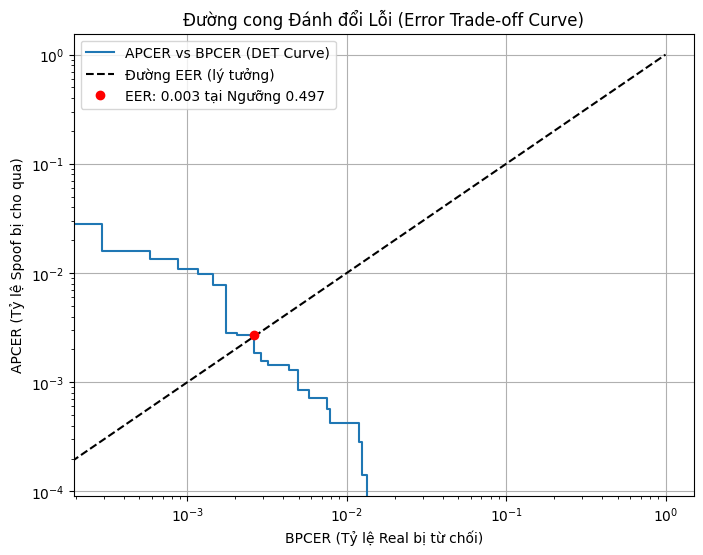

In [21]:
if 'fpr' in locals():
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, fnr, label='APCER vs BPCER (DET Curve)')
    plt.plot([0, 1], [0, 1], 'k--', label='Đường EER (lý tưởng)')
    
    plt.plot(fpr[np.nanargmin(np.abs(fnr - fpr))], 
             fnr[np.nanargmin(np.abs(fnr - fpr))], 
             'ro', 
             label=f'EER: {eer_value:.3f} tại Ngưỡng {eer_thresh:.3f}')

    plt.xlabel('BPCER (Tỷ lệ Real bị từ chối)')
    plt.ylabel('APCER (Tỷ lệ Spoof bị cho qua)')
    plt.title('Đường cong Đánh đổi Lỗi (Error Trade-off Curve)')
    plt.legend()
    plt.grid(True)
    plt.xscale('log') # Thử dùng thang log cho BPCER
    plt.yscale('log') # Thử dùng thang log cho APCER
    plt.show()
else:
    print("LỖI: Chưa chạy đánh giá (fpr không tồn tại). Vui lòng chạy cell trước.")

# Phần 5: Thực nghiệm mô hình

In [22]:
# Cài đặt insightface và onnxruntime-gpu
!pip install insightface onnxruntime-gpu

print("Cài đặt insightface hoàn tất.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 9.3 MB/s eta 0:00:0000:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of mkl-fft to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-random to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-umath to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 MB 5.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.2/323.2 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━

**Bước 1: Import thư viện và tải detector**

In [23]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
import cv2
import numpy as np
import os
from PIL import Image
import torch.nn.functional as F
import time
import insightface # <-- Thư viện mới

# --- Thiết lập ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Sử dụng thiết bị: {DEVICE}")

Sử dụng thiết bị: cuda


**Bước 2: Tải bộ phát hiện mặt (RetinaFace)**

In [24]:
# Tải bộ phát hiện mặt (Detector) - RetinaFace
try:
    # 'app' là một trình phân tích, nó chứa cả detector
    # 'buffalo_l' là model detector/recognition nhanh và tốt
    # providers=['CUDAExecutionProvider'] là bắt buộc để dùng GPU
    app_detector = insightface.app.FaceAnalysis(
        name='buffalo_l', 
        providers=['CUDAExecutionProvider' if DEVICE.type == 'cuda' else 'CPUExecutionProvider']
    )
    # Chuẩn bị model (ctx_id=0 là GPU 0, -1 là CPU)
    app_detector.prepare(ctx_id=0 if DEVICE.type == 'cuda' else -1, det_size=(640, 640))
    print("Đã tải RetinaFace (insightface) làm bộ phát hiện mặt.")
except Exception as e:
    print(f"Lỗi khi tải insightface: {e}")
    print("Hãy chắc chắn bạn đã chạy Bước 1 và bật GPU (nếu có).")
    app_detector = None

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:03<00:00, 87209.06KB/s] 


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

**Bước 3: Định nghĩa lại kiến trúc ResNet18 và tải lại tham số mô hình**

In [25]:
# 1. Định nghĩa lại kiến trúc (phải giống hệt lúc train)
CLASS_NAMES = ['real', 'spoof'] 
fas_model = models.resnet18(weights=None) # Không cần pre-trained
num_ftrs = fas_model.fc.in_features
fas_model.fc = nn.Linear(num_ftrs, len(CLASS_NAMES))

# 2. Tải trọng số 'best_fas_model.pth'
# !!! CẬP NHẬT ĐƯỜNG DẪN NÀY !!!
MODEL_PATH = "/kaggle/input/fas-model/Face_Anti_Spoofing_Model_Standard_Version_V2.pth" 
# (Ví dụ: "/kaggle/input/my-fas-model-weights/best_fas_model.pth")

try:
    fas_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    fas_model.to(DEVICE)
    fas_model.eval() # BẮT BUỘC: Chuyển sang chế độ dự đoán
    print(f"Đã tải model FAS từ '{MODEL_PATH}'.")
except Exception as e:
    print(f"LỖI: Không tải được model. Kiểm tra lại đường dẫn: {e}")
    fas_model = None

Đã tải model FAS từ '/kaggle/input/fas-model/Face_Anti_Spoofing_Model_Standard_Version_V2.pth'.


**Bước 4: Định nghĩa test_transforms và hàm dự đoán**

In [26]:
# Định nghĩa test_transforms (phải giống hệt lúc train)
INPUT_SIZE = 224
test_transforms = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def check_liveness_pytorch(image_bgr, model, transform, device):
    """
    Nhận vào ảnh BGR (đã cắt), trả về (is_real, score, label_name)
    """
    if model is None: return True, 1.0, "Real"

    # Chuyển BGR (OpenCV) -> RGB (PIL)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_pil = Image.fromarray(image_rgb)
    
    # Áp dụng transform
    image_tensor = transform(image_pil).unsqueeze(0).to(device) # [1, 3, 224, 224]
    
    with torch.no_grad():
        outputs = model(image_tensor)
        probs = F.softmax(outputs, dim=1)
        score_tensor, pred_tensor = torch.max(probs, dim=1)
        
        pred_class_index = pred_tensor.item() # Index (0 hoặc 1)
        score = score_tensor.item()
        
    # Lấy tên nhãn
    label_name = CLASS_NAMES[pred_class_index] # 'real' hoặc 'spoof'
    is_real = (label_name == "real")
    
    return is_real, score, label_name

In [28]:
VIDEO_INPUT_PATH = "/kaggle/input/testdata/Real.mp4"
VIDEO_OUTPUT_PATH = "/kaggle/working/Output_Real.mp4"

# Kiểm tra xem file có tồn tại không
if not os.path.exists(VIDEO_INPUT_PATH):
    print(f"LỖI: Không tìm thấy file '{VIDEO_INPUT_PATH}'.")
    # Nếu đang test, tải video mẫu:
    # !wget https://github.com/intel-iot-devkit/sample-videos/raw/master/face-demographics-walking.mp4 -O test_video.mp4
    # VIDEO_INPUT_PATH = "test_video.mp4"
else:
    print(f"Sẵn sàng xử lý file: {VIDEO_INPUT_PATH}")

if fas_model is not None and app_detector is not None:
    cap = cv2.VideoCapture(VIDEO_INPUT_PATH)
    
    # Thiết lập file output
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    out = cv2.VideoWriter(VIDEO_OUTPUT_PATH, cv2.VideoWriter_fourcc(*'MP4V'), fps, (frame_width, frame_height))
    
    print(f"Đang xử lý video '{VIDEO_INPUT_PATH}' với RetinaFace...")
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        # 1. Phát hiện (Detect) MỚI -> Lấy Bounding Box
        # KHÔNG CẦN ẢNH XÁM
        # app_detector.get() trả về một list các đối tượng "Face"
        faces = app_detector.get(frame)

        # 2. Lặp qua từng bounding box
        for face in faces:
            # Lấy bounding box [x1, y1, x2, y2]
            bbox = face.bbox.astype(int)
            # Đảm bảo tọa độ không bị âm
            x1 = max(0, bbox[0])
            y1 = max(0, bbox[1])
            x2 = min(frame_width, bbox[2])
            y2 = min(frame_height, bbox[3])
            
            # 3a. Cắt (Crop)
            cropped_face = frame[y1:y2, x1:x2]
            if cropped_face.size == 0: continue
                
            # 3b. Phân loại (Classify)
            is_real, score, label_name = check_liveness_pytorch(cropped_face, fas_model, test_transforms, DEVICE)
            
            # 3c. Lấy kết quả
            if is_real:
                color = (0, 255, 0) # Xanh lá
                label = f"REAL: {score:.2f}"
            else:
                color = (0, 0, 255) # Đỏ
                label = f"SPOOF: {score:.2f}"
            
            # 3d. Vẽ (Draw) - Dùng (x1,y1) và (x2,y2)
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(frame, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        # Ghi khung hình đã vẽ
        out.write(frame)

    cap.release()
    out.release()
    print(f"Xử lý hoàn tất! Video đã lưu tại: {VIDEO_OUTPUT_PATH}")
else:
    print("Không thể chạy. Vui lòng kiểm tra model FAS và RetinaFace (app_detector).")

Sẵn sàng xử lý file: /kaggle/input/testdata/Real.mp4
Đang xử lý video '/kaggle/input/testdata/Real.mp4' với RetinaFace...


OpenCV: FFMPEG: tag 0x5634504d/'MP4V' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


Xử lý hoàn tất! Video đã lưu tại: /kaggle/working/Output_Real.mp4
